In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# python libs
import glob
import os
import pickle
import random
import copy
import logging
import hashlib

from collections import defaultdict
from typing import List, Tuple, Optional, Dict, NamedTuple, Union, Callable
import itertools
import os
import string
from pathlib import Path

In [3]:
# IO
from tqdm import tqdm
from IPython.display import display, clear_output

In [4]:
# data libs
import pandas as pd
import numpy as np
import seaborn as sns

In [5]:
# plotting
import matplotlib as mpl
import matplotlib.pyplot as plt

In [6]:
# bio stuff
from Bio.Seq import Seq
from Bio import SeqIO

In [7]:
# sklearn
import sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.manifold import TSNE
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, WhiteKernel, ConstantKernel as C

# hyperopt
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval

# scipy
from scipy.spatial.distance import squareform, pdist, cdist
from scipy.stats import spearmanr

# statsmodels
import statsmodels
import statsmodels.api as sm

# elastic net
from glmnet import ElasticNet

In [8]:
# PLMs
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler, random_split, TensorDataset
import torch.optim as optim
from torch.optim import Adam

from torch.nn import HuberLoss, MSELoss

# ESM
import esm

In [9]:
sm.__version__

'0.14.1'

In [10]:
import sys
sys.path.append('/data/mhoffert/fiererlab/adenylate_kinase_ogt/')

# Notes

Notebok for specific validations proposed by Dru in revision of "Predicting bacterial optimal growth temperatures using structural information"

# Get training data

In [11]:
from src.models.utils import construct_msa_dataset, scale_ogts, unscale_ogts, reload_model, compute_gaussian_weights
from src.models.utils import plot_performance

In [12]:
from src.models.embeddings import get_embeddings, get_random_context

In [13]:
# get dataset
full_msa_dataset = construct_msa_dataset('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/high_qual_alignments/backbone.filtered_only.afa')

# scale ogts
full_msa_dataset, scaler = scale_ogts(full_msa_dataset)

print('Number of observations:', len(full_msa_dataset))

Number of observations: 8532


In [14]:
# save scaler
with open('./../data/predictive_models/ogt_scaler.pickle', 'wb') as handle:
    pickle.dump(scaler, handle)

# Reload ESM embeddings and context

In [16]:
# scaler
with open('./../data/predictive_models/ogt_scaler.pickle', 'rb') as handle:
    ogt_scaler = pickle.load(handle)

In [17]:
# msa datasets
with open('./../data/predictive_models/supporting_data/even_msa_dataset.pickle', 'rb') as handle:
    even_msa_dataset = pickle.load(handle)

with open('./../data/predictive_models/supporting_data/corkrey_msa_dataset.pickle', 'rb') as handle:
    corkrey_msa_dataset = pickle.load(handle)

print(f'Even: {len(even_msa_dataset)}, Corkrey: {len(corkrey_msa_dataset)}')

Even: 1227, Corkrey: 230


In [18]:
# even dataset
with open('./../data/esm_msa/even_temps.pickle', 'rb') as handle:
    even_temps = pickle.load(handle)

with open('./../data/esm_msa/even_full_context.pickle', 'rb') as handle:
    even_full_context = pickle.load(handle)

with open('./../data/esm_msa/even_full_embeddings.pickle', 'rb') as handle:
    even_full_embeddings = pickle.load(handle)

print(f'Even: {even_full_embeddings.shape}, {len(even_temps)}')

Even: (1227, 215, 768), 1227


In [19]:
# corkrey dataset
with open('./../data/esm_msa/corkrey_temps.pickle', 'rb') as handle:
    corkrey_temps = pickle.load(handle)

with open('./../data/esm_msa/corkrey_full_context.pickle', 'rb') as handle:
    corkrey_full_context = pickle.load(handle)

with open('./../data/esm_msa/corkrey_full_embeddings.pickle', 'rb') as handle:
    corkrey_full_embeddings = pickle.load(handle)

print(f'Corkrey: {corkrey_full_embeddings.shape}, {len(corkrey_temps)}')

Corkrey: (230, 215, 768), 230


In [221]:
np.array(corkrey_full_context).shape

(230, 8, 2)

In [20]:
# e_w_c dataset (even embedded with corkrey as context)
with open('./../data/esm_msa/e_w_c_temps.pickle', 'rb') as handle:
    e_w_c_temps = pickle.load(handle)

# with open('./../data/esm_msa/e_w_c_full_context.pickle', 'rb') as handle:
#     e_w_c_full_context = pickle.load(handle)

with open('./../data/esm_msa/e_w_c_full_embeddings.pickle', 'rb') as handle:
    e_w_c_full_embeddings = pickle.load(handle)

print(f'Even embedded using Corkrey: {e_w_c_full_embeddings.shape}, {len(e_w_c_temps)}')

Even embedded using Corkrey: (1227, 215, 768), 1227


In [265]:
# c_w_e dataset
with open('./../data/esm_msa/c_w_e_temps.pickle', 'rb') as handle:
    c_w_e_temps = pickle.load(handle)

with open('./../data/esm_msa/c_w_e_context.pickle', 'rb') as handle:
    c_w_e_full_context = pickle.load(handle)

with open('./../data/esm_msa/c_w_e_full_embeddings.pickle', 'rb') as handle:
    c_w_e_full_embeddings = pickle.load(handle)

print(f'Corkrey embedded using Even: {c_w_e_full_embeddings.shape}, {len(c_w_e_temps)}')

Corkrey embedded using Even: (230, 215, 768), 230


# Load ESM model

In [22]:
# load ESM model
esm_msa_model, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
conv = alphabet.get_batch_converter()

# turn off gradients
for name, param in esm_msa_model.named_parameters():
    param.requires_grad = False

In [23]:
esm.__version__

'2.0.0'

## Number 1: Hot-encoded models

In [214]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNetCV
from src.models.utils import plot_performance, assess_model

In [222]:

def hot_encode_site(site, msa, categories):
    ''' 
    function to hot encode a site from an msa object
    msa: list (label, sequence, OGT)
    returns a pd.DataFrame
    '''
    # if a sequence only has two residues, only return 3 [ the two residues + gap for all others]
    vals = np.array([i[1][site] if i[1][site] in categories else '-' for i in msa]).reshape(-1, 1)

    encoder = OneHotEncoder(sparse_output=False).fit(vals)

    encoded_chars = encoder.transform(vals)

    encoded_df = pd.DataFrame(index=[i[0] for i in msa],
             data=encoded_chars,
             columns=encoder.categories_)
    
    return encoded_df

def add_dummy(df, dummy_val):
    if not dummy_val in df.columns:
        df[dummy_val] = 0

    return df

In [216]:
enets = {}
preds = []
for site in range(len(even_msa_dataset[0][1])):
    corkrey_categories = set([i[1][site] for i in corkrey_msa_dataset] + ['-'])
    even_categories = set([i[1][site] for i in even_msa_dataset] + ['-'])
    categories = list(corkrey_categories.intersection(even_categories))
    
    
    even_encoded = hot_encode_site(site, even_msa_dataset, categories)
    even_encoded = add_dummy(even_encoded, '-')
    # even_encoded = add_dummy(even_encoded, '*')
    display(even_encoded.shape)
    
    corkrey_encoded = hot_encode_site(site, corkrey_msa_dataset, categories)
    corkrey_encoded = add_dummy(corkrey_encoded, '-')
    # corkrey_encoded = add_dummy(corkrey_encoded, '*')
    display(corkrey_encoded.shape)

    enet = ElasticNetCV(l1_ratio=[0.01, 0.1, 0.25, .5, .75, .9, 0.99, 1.0], cv=5, 
                    n_alphas=100, max_iter=10000, selection='random', tol=1e-3,
                        precompute=False,
                   random_state=123, n_jobs=24)
    enet.fit(even_encoded, even_temps)
    # col_lm = ElasticNet(alpha=0.1, n_jobs=5)
    # col_lm.fit(X, even_temps)
    enets[site] = enet
    
    # lm = sm.OLS(even_temps, even_encoded.values).fit()
    # lm.fit(corkrey_full_embeddings[:, 0, :], corkrey_temps)
    preds.append(list(enet.predict(corkrey_encoded)))

    clear_output(wait=True)

(1227, 19)

(230, 19)

<Axes: >

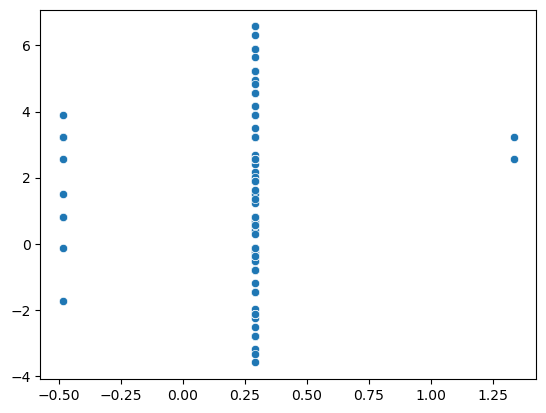

In [218]:
sns.scatterplot(x=preds[5], y=corkrey_temps)

0.5994331990512118


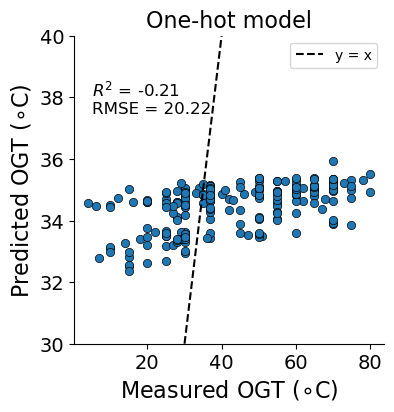

In [323]:
fig, ax = plt.subplots(figsize=(4,4))
y_true = unscale_ogts(corkrey_temps, scaler)
y_pred = unscale_ogts(np.array(preds).mean(0), scaler)
sns.scatterplot(x=y_true, 
                y=y_pred,
               edgecolor='k')

plt.plot((30, 40), (30, 40), linestyle='--', color='k', label='y = x')
lgd = ax.legend()

assessment, (r2, rmse, spr) = assess_model(y_true, y_pred)
print(spr)
ax.annotate(f'$R^2$ = {r2:.2f}\nRMSE = {rmse:.2f}', 
            xy=(5, 38), va='center', fontsize=12)

ax.set_xlabel('Measured OGT ($\circ$C)', fontsize=16)
ax.set_ylabel('Predicted OGT ($\circ$C)', fontsize=16)
sns.despine()
ax.set_title('One-hot model', fontsize=16)
plt.tick_params(labelsize=14)
ax.set_ylim(30, 40)
plt.savefig('./../data/figures/models/onehot.svg', bbox_inches='tight')
plt.savefig('./../data/figures/models/onehot.png', dpi=400, bbox_inches='tight')

#### Notes
SpearmanR is 0.60 - actually not bad. Maybe need to add CLS to make it truly equivalent?

In [307]:
# Save site-specific SPRs
onehot_site_sprs = pd.Series()
for site in range(len(preds)):
    y_true = unscale_ogts(corkrey_temps, scaler)
    y_pred = unscale_ogts(preds[site], scaler)
    onehot_site_sprs.loc[site] = spearmanr(y_true, y_pred)[0]
clear_output()

<Axes: ylabel='Count'>

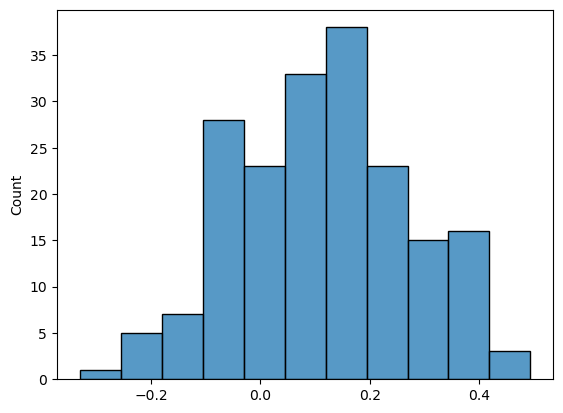

In [308]:
sns.histplot(onehot_site_sprs)

In [310]:
onehot_site_sprs.to_csv('./../data/predictive_models/supporting_data/onehot_site_sprs.tsv', sep='\t')

# Likelihood of proteins in MSA-Transformer

In [ ]:
# get the likelihoods of each protein from MSA Transformer
# sum of logits?

In [325]:
def get_sequence_log_likelihoods(esm_model, converter, data_to_embed, training_context, context_inds,
                                verbose=False):
    esm_model.eval()
    log_likelihoods = []

    with torch.no_grad():
        for ind, item in enumerate(tqdm(data_to_embed)):

            # construct msa context
            context = [(training_context[c][0], training_context[c][1]) for c in context_inds[ind]]
            msa = [(item[0], item[1])] + context
            _, _, tokens = converter(msa) # Shape: (1, num_seqs, seq_len)

            # retrieve logits
            results = esm_model(tokens, return_contacts=False)
            logits = results["logits"] # this is (1, num_seqs, seq_len, alphabet_size)
            if verbose:
                print(logits.shape)

            # log likelihoods
            # only query
            query_logits = logits[0, 0, :, :] # should be 215 x 23ish
            # query_tokens = tokens[0, 0, :] 

            # log and softmax
            log_probs = F.log_softmax(query_logits, dim=-1)

            # gather log-probs for all tokens
            token_log_probs = torch.gather(
                log_probs, 
                dim=-1, 
                index=query_tokens.unsqueeze(-1)
            ).squeeze(-1)

            # sum log probs for the tokens
            seq_log_likelihood = token_log_probs.sum().item()
            log_likelihoods.append(seq_log_likelihood)

    return np.array(log_likelihoods)

In [233]:
def get_context_id(msa_dataset, sequence):
    '''
    Just get the index of a sequence in an msa dataset
    used to identify the context, since I returned the context itself (i.e. list of sequence IDs)
    and not the index
    '''
    i = 0
    while msa_dataset[i][0] != sequence[0]:
        i += 1
    return i

In [ ]:
context_ints = []
for sequence in range(len(even_full_context)):
    context_ints.append([])
    for i in range(8):
        context_ints[sequence].append(get_context_id(even_msa_dataset, even_full_context[sequence][i]))

print(np.array(context_ints).shape)

In [266]:
assert even_full_context[0][0][0] == even_msa_dataset[328][0]

In [248]:
# to ensure consistency, we are using the same context used to generate the original embeddings
even_lls = get_sequence_log_likelihoods(esm_msa_model, conv, even_msa_dataset, 
                             even_msa_dataset, context_ints)

100%|███████████████████████████████████████| 1227/1227 [13:44<00:00,  1.49it/s]


0.11978780333454613


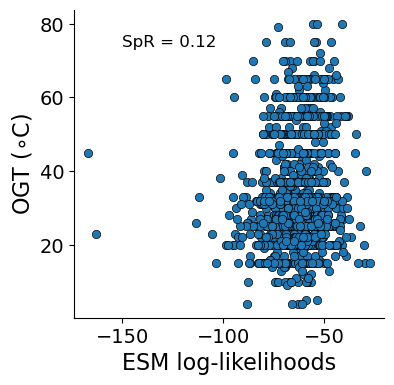

In [324]:
fig, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(x=even_lls,
                y=unscale_ogts(even_temps, scaler),
               edgecolor='k')

assessment, (r2, rmse, spr) = assess_model(even_lls, 
                                           unscale_ogts(even_temps, scaler))
print(spr)
ax.annotate(f'SpR = {spr:.2f}', 
            xy=(-150, 75), va='center', fontsize=12)

ax.set_xlabel('ESM log-likelihoods', fontsize=16)
ax.set_ylabel('OGT ($\circ$C)', fontsize=16)
sns.despine()
# ax.set_title('One-hot model', fontsize=16)
plt.tick_params(labelsize=14)
# ax.set_ylim(30, 40)
plt.savefig('./../data/figures/models/ESM_lls.svg', bbox_inches='tight')
plt.savefig('./../data/figures/models/ESM_lls.png', dpi=400, bbox_inches='tight')

In [313]:
even_ll_series = pd.Series(index=[i[0] for i in even_msa_dataset], data=even_lls)

In [315]:
even_ll_series.to_csv('./../data/predictive_models/supporting_data/even_lls.tsv', sep='\t')

# One layer model

In [262]:
even_l1_embeddings = get_embeddings(esm_msa_model,
                                   conv,
                                   even_msa_dataset,
                                   even_msa_dataset,
                                   context_ints, layer=1,
                                    return_mean=False
                                   )

100%|███████████████████████████████████████| 1227/1227 [13:34<00:00,  1.51it/s]


In [263]:
even_l6_embeddings = get_embeddings(esm_msa_model,
                                   conv,
                                   even_msa_dataset,
                                   even_msa_dataset,
                                   context_ints, layer=6,
                                    return_mean=False
                                   )

100%|███████████████████████████████████████| 1227/1227 [14:26<00:00,  1.42it/s]


In [295]:
even_l1_embeddings = even_l1_embeddings[0]
even_l6_embeddings = even_l6_embeddings[0]
print(even_l1_embeddings.shape)
print(even_l6_embeddings.shape)

(1227, 215, 768)
(1227, 215, 768)


In [285]:
corkrey_context_ints = get_random_context(even_msa_dataset, 
                                    n_contexts=len(corkrey_msa_dataset),
                                    context_size=8,
                                    self=False
                                   )

In [286]:
# now corkrey
# didn't save the context right, so we need to generate a new context

# corkrey_context_ints = []
# for sequence in range(len(c_w_e_full_context)):
#     corkrey_context_ints.append([])
#     for i in range(8):
#         corkrey_context_ints[sequence].append(get_context_id(corkrey_msa_dataset, c_w_e_full_context[sequence][i]))

# print(np.array(corkrey_context_ints).shape)
# corkrey_context_ints[0]

# make sure the ints match the context
# assert corkrey_full_context[0][0][0] == corkrey_msa_dataset[121][0]

In [287]:
corkrey_l1_embeddings = get_embeddings(esm_msa_model,
                                   conv,
                                   corkrey_msa_dataset,
                                   even_msa_dataset,
                                   corkrey_context_ints, layer=1,
                                    return_mean=False
                                   )

100%|█████████████████████████████████████████| 230/230 [02:58<00:00,  1.29it/s]


In [288]:
corkrey_l6_embeddings = get_embeddings(esm_msa_model,
                                   conv,
                                   corkrey_msa_dataset,
                                   even_msa_dataset,
                                   corkrey_context_ints, layer=6,
                                    return_mean=False
                                   )

100%|█████████████████████████████████████████| 230/230 [03:01<00:00,  1.27it/s]


In [293]:
corkrey_l1_embeddings = corkrey_l1_embeddings[0]
corkrey_l6_embeddings = corkrey_l6_embeddings[0]
print(corkrey_l1_embeddings.shape)
print(corkrey_l6_embeddings.shape)

(230, 215, 768)
(230, 215, 768)


In [ ]:
for layer, train_embeddings, test_embeddings in zip(['layer1'], #'layer6'],
                             [even_l1_embeddings], # even_l6_embeddings],
                             [corkrey_l1_embeddings]): #, corkrey_l6_embeddings]):
    
    # train Layer 1 and layer 6 models
    title = f'ENET CV, inds, {layer}, training: Even'
    label = f'even_enetcv_ind_{layer}'
    
    # fit models
    even_col_enets = {}
    even_col_scalers = {}
    for col in range(train_embeddings.shape[1]):
        display(col)
        clear_output(wait=True)
        col_embedding = train_embeddings[:, col, :]
        even_col_scalers[col] = StandardScaler()
        X = even_col_scalers[col].fit_transform(col_embedding)
        # col_lm = sm.WLS(even_temps, X).fit()
        enet = ElasticNetCV(l1_ratio=[0.01, 0.1, 0.25, .5, .75, .9, 0.99, 1.0], cv=5, 
                        n_alphas=100, max_iter=10000, selection='random', tol=1e-3, precompute=False,
                       random_state=123, n_jobs=24)
        enet.fit(X, even_temps)
        # col_lm = ElasticNet(alpha=0.1, n_jobs=5)
        # col_lm.fit(X, even_temps)
        even_col_enets[col] = enet
    
    # predict
    corkrey_col_preds = []
    for col in range(len(even_col_enets)):
        display(col)
        clear_output(wait=True)
        corkrey_col_preds.append(even_col_enets[col].predict(even_col_scalers[col].transform(test_embeddings[:, col, :])))
    
    corkrey_mean_preds = np.array(corkrey_col_preds).mean(axis=0)

    enet_results = {'best_model':even_col_enets,
           'best_params':'', #dict((k, i.params) for k,i in even_col_enets.items()),
           'predictions':corkrey_mean_preds,
          'full_predictions':np.array(corkrey_col_preds),
           'true_values': c_w_e_temps,
            'true_labels':[i[0] for i in corkrey_msa_dataset],
           'statsmodels_version':statsmodels.__version__,
           'metadata':{'type':f'array of {str(lm)}',
                       'input_shape':test_embeddings.shape,
                       'title':title,
                       'label':label
                      }
          }

    plot_performance(unscale_ogts(enet_results['true_values'], scaler), 
                 unscale_ogts(enet_results['predictions'], scaler),
                 title=title,
                 show=True,
                 save_loc=f'./../data/figures/models/{label}.svg')

20

In [320]:
label

'even_enetcv_ind_layer1'

In [321]:
enet_results['scalers'] = even_col_scalers

print('dumping...')
with open(f'./../data/predictive_models/{label}.pickle', 'wb') as handle:
    pickle.dump(enet_results, handle)
print('done.')

dumping...
done.


<Axes: >

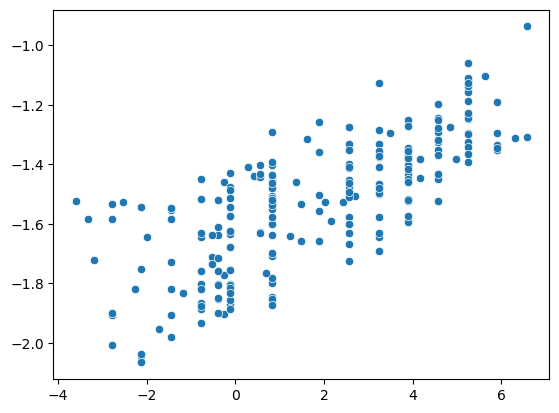

In [322]:
sns.scatterplot(y=even_col_enets[0].predict(even_col_scalers[col].transform(corkrey_l1_embeddings[:, 0, :])),
                x=corkrey_temps)

## Make figure of all validation attempts